In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from Grape import GrapeLBFGS as gp
from Grape import *
from helpful_functions import *
%load_ext autoreload
%autoreload 2

In [2]:
def make_H(Nc: int, Nq: int, g: float, alpha: float) -> tuple[qt.Qobj, qt.Qobj]:
    """
    Build drift and control Hamiltonians for detuning control:

      H(t) = H_d + Δ(t) * H_c

    where:
      - H_d contains JC exchange + transmon Kerr anharmonicity
      - H_c is the transmon number operator n_q = a_q† a_q
    Tensor order: cavity ⊗ transmon.

    Returns:
      H_d, H_c
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    H_c = n_q
    return H_d, H_c


In [3]:
Nr_subspace_dim = 5          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq_subspace_dim = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 10     # total cavity dim: includes higher levels
Nq_big = 5      # total qubit dim: includes higher levels

g = 0.59 * 2*np.pi        # coupling (angular units)
alpha = -168.4 * 2*np.pi # transmon anharmonicity (angular units)
dressed_detuning = 164 * 2*np.pi  # detuning between cavity and transmon for adiabetic dressed frame 165

drive_parameters = {
    'N_c': Nc_big,
    'N_q': Nq_big,   
    'detuning': dressed_detuning,  # qubit-resonator detuning in angular frequency
    'gbs': g,       # qubit-resonator coupling strength in angular frequency
}
results = dchi_H(drive_parameters, alpha)

evecs_qobj = results['sorted_dict']['evecs_qobj']
w_r_dressed = results['dressed_operators']['w_r_dressed']
w_q_dressed = results['dressed_operators']['w_q_dressed']
a_r_dressed = results['dressed_operators']['a_r']
a_q_dressed = results['dressed_operators']['a_q']

chi = results['chi_dict']['chi_list'][0]  # dispersive shift for 0->1 transition

a_r = results['Hamiltonian_dict']['a_r']
a_q = results['Hamiltonian_dict']['a_q']
n_r = a_r.dag() * a_r
n_q = a_q.dag() * a_q

H0_exact = results['Hamiltonian_dict']['H0']
H0_approx = w_r_dressed * a_r_dressed.dag() * a_r_dressed + w_q_dressed * a_q_dressed.dag() * a_q_dressed + chi * a_r_dressed.dag() * a_r_dressed * a_q_dressed.dag() * a_q_dressed

U_cross_target = (-1j * np.pi * (n_r * n_q)).expm() # this is the cross-Kerr needed

dressed_target = evecs_qobj * U_cross_target * evecs_qobj.dag() # target for dressed operators
gauge_ops = [evecs_qobj*n_r*evecs_qobj.dag(), evecs_qobj*n_q*evecs_qobj.dag()] # gauge ops for dressed frame
projector = projector_onto_states([results['sorted_dict']['evecs_sorted'][n_r][n_q] for n_r in range(Nr_subspace_dim) for n_q in range(Nq_subspace_dim)])

In [4]:
T_gate = np.pi/chi  # gate time for cross-Kerr pi. this is positive
f = unitary_projected_fidelity(dressed_target, ((1j*w_r_dressed * gauge_ops[0]*T_gate + 1j*w_q_dressed * gauge_ops[1]*T_gate).expm())*(-1j*H0_approx*T_gate).expm(), projector)
print(f)  # should be close to 1

f = unitary_projected_fidelity(dressed_target, ((1j*w_r_dressed * gauge_ops[0]*T_gate + 1j*w_q_dressed * gauge_ops[1]*T_gate).expm())*(-1j*H0_exact*T_gate).expm(), projector)
print(f)  # should be close to 1. exactly one if nq and nr subspaces are 2-level. as n_r increases fidelity drops. fidelity increases as the dressed detuning increases (better dispersive approx)
print(T_gate)

1.0000000000001048
0.9077760913444415
3.184379547629459


In [5]:
n_steps = 300
dt = T_gate / n_steps
det_min = 1.0 * 2*np.pi
det_max = 1000.0 * 2*np.pi

opt = gp(
    H_drift = make_H(Nc_big, Nq_big, g, alpha)[0],
    H_controls = [make_H(Nc_big, Nq_big, g, alpha)[1]],
    U_target = dressed_target,
    dt = dt,
    n_steps = n_steps,
    cost_type= "projected",
    projector = projector,
    derivative= "frechet",
    gauge_ops=gauge_ops
)

# opt.add_l2_amplitude_penalty(lam=1e-3)                          # discourage huge amplitudes
# opt.add_smoothness_penalty(lam=1e-5)                            # encourage smooth pulses

pulses0 = dressed_detuning*np.ones((n_steps, 1)) # + 0.01*dressed_detuning*np.random.randn(n_steps, 1)  # initial pulse: constant detuning
theta0 = [w_r_dressed*T_gate, w_q_dressed*T_gate]

# pulses0, theta0 = load_pulses_theta("results/run1.npz")
options = {
        # <-- KEY ONE: make projected-gradient tolerance smaller => later termination
        "gtol": 1e-8,        # default is ~1e-5; try 1e-8, 1e-10, 1e-12

        # if you're stopping due to tiny objective improvements, tighten this too:
        "ftol": 1e-9,        # default ~2e-9; smaller => requires more improvement to stop

        # optional: allow more line-search steps per iteration
        "maxls": 50,
    }

out = opt.optimize(
    maxiter=4000,
    pulse_bounds=[(det_min, det_max)],
    pulses0=pulses0,
    theta0 = theta0,
    scipy_options=options
) # initial fidelity is small need to fix something to start with ideal case

Fidelity: 0.907776091344435
Fidelity: 0.782515670356072
Fidelity: 0.9415854883628814
Fidelity: 0.9472726514750595
Fidelity: 0.9615269074307787
Fidelity: 0.9615382979382209
Fidelity: 0.9615405280591267
Fidelity: 0.961548005619286
Fidelity: 0.9615910731192792
Fidelity: 0.9617275657618601
Fidelity: 0.9620576109648167
Fidelity: 0.9629235389952833
Fidelity: 0.965026816381321
Fidelity: 0.9697040697749436
Fidelity: 0.9774678574629249
Fidelity: 0.8566789254712339
Fidelity: 0.9786320143768588
Fidelity: 0.9832998013578176
Fidelity: 0.9857596927688544
Fidelity: 0.9859719482290171
Fidelity: 0.9859725658556762
Fidelity: 0.9859730522816686
Fidelity: 0.9859738994110617
Fidelity: 0.9859765525061277
Fidelity: 0.9859829411992402
Fidelity: 0.9859993753772914
Fidelity: 0.9860374518868382
Fidelity: 0.9861135610680937
Fidelity: 0.9862204574215647
Fidelity: 0.9859146751872035
Fidelity: 0.9862314993896285
Fidelity: 0.9863063590017207
Fidelity: 0.9863200799525863
Fidelity: 0.9863227975470384
Fidelity: 0.986323

Fidelity: 0.9863780469987874
Final fidelity: 0.9863780469987874


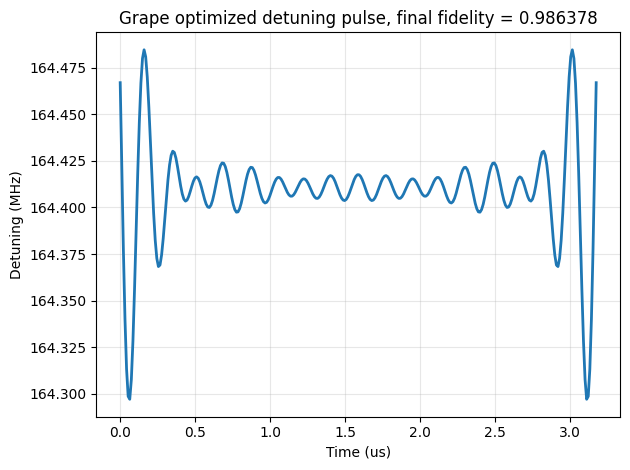

dressed_detuning (MHz): 164.0


In [6]:
# --- Final fidelity ---
F_final = opt.fidelity(out["pulses_opt"], theta=out["theta_opt"])
print("Final fidelity:", F_final)

t_us = np.arange(n_steps) * dt  # dt is in us in your codebase (T_gate/n_steps)
pulse_MHz = out["pulses_opt"][:, 0] / (2*np.pi)  # convert rad/ns -> MHz

plt.figure()
plt.plot(t_us, pulse_MHz, linewidth=2)

plt.xlabel("Time (us)")
plt.ylabel("Detuning (MHz)")
plt.title(f"Grape optimized detuning pulse, final fidelity = {F_final:.6f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("dressed_detuning (MHz):", dressed_detuning/(2*np.pi))

In [ ]:
opt.save_results("Grape_results/run2.npz", out)

In [2]:
q = load_qobjs("Grape_results/run1.npz")
pulses0, theta0 = load_pulses_theta("Grape_results/run1.npz")
parameters_dict = load_parameters_dict("Grape_results/run1.npz")

H0 = q["H_drift"]
Hc = q["H_controls"]
Ut = q["U_target"]
P  = q["projector"]
gauge_ops = q["gauge_ops"]

U_final = propagate(H0, Hc, dt = parameters_dict["dt"], pulses = pulses0)
G = gauge_unitary(gauge_ops, theta0)
g_unitary = G * U_final

# write unitary in terms of the dressed basis
# unitary_dressed = evecs_qobj.dag() * g_unitary * evecs_qobj

fidelity = unitary_projected_fidelity(Ut, g_unitary, P)
print("Fidelity check:", fidelity)

Fidelity check: 0.986364900105326
